## 02 — Baseline Models: XGBoost vs RandomForest

This notebook consolidates all baseline training, evaluation, SHAP explainability, and
cross-model comparison for GS-BRCA and GS-COAD.

**Models:** XGBoost (early fusion) · RandomForest (early fusion)  
**Evaluation:** Patient-level stratified 5-fold CV · Metrics: Precision, Recall, F1, NMI, ARI  
**Explainability:** SHAP via `TreeExplainer`

> *Academic research prototype — not for clinical use.*

## 1 · Setup

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Image, Markdown

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
sys.path.insert(0, ROOT)

from src.utils import load_config, set_seeds

set_seeds(42)
config = load_config()

RESULTS = config['paths']['results']
METRICS_DIR = os.path.join(RESULTS, 'metrics')
PLOTS_DIR = os.path.join(RESULTS, 'plots')
SHAP_DIR = os.path.join(RESULTS, 'shap')

CANCER_TYPES = config['project']['cancer_types']
METRIC_COLS = ['precision', 'recall', 'f1', 'nmi', 'ari']
MODALITY_LABELS = {'mrna': 'mRNA', 'mirna': 'miRNA', 'methy': 'Methylation', 'cnv': 'CNV'}

print(f'Project root: {ROOT}')
print(f'Cancer types: {CANCER_TYPES}')

Project root: e:\Projects\multi-omics-cancer-subtype-classifier
Cancer types: ['GS-BRCA', 'GS-COAD']


## 2 · Load Per-Fold Metrics

In [2]:
def load_metrics(model_key, cancer_short):
    """Load per-fold metrics CSV, dropping the mean+/-std summary row."""
    path = os.path.join(METRICS_DIR, f'{model_key}_{cancer_short.lower()}_metrics.csv')
    df = pd.read_csv(path)
    # Keep only numeric fold rows
    df = df[pd.to_numeric(df['fold'], errors='coerce').notna()].copy()
    df['fold'] = df['fold'].astype(int)
    for c in METRIC_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

metrics_data = {}
for ct in CANCER_TYPES:
    cs = ct.split('-')[1]
    for mk in ['xgb', 'rf']:
        key = f'{mk}_{cs}'
        metrics_data[key] = load_metrics(mk, cs)
        print(f'{key}: {len(metrics_data[key])} folds loaded')

xgb_BRCA: 5 folds loaded
rf_BRCA: 5 folds loaded
xgb_COAD: 5 folds loaded
rf_COAD: 5 folds loaded


### 2.1 · Per-Fold Results — GS-BRCA

In [3]:
for mk, label in [('xgb', 'XGBoost'), ('rf', 'RandomForest')]:
    df = metrics_data[f'{mk}_BRCA']
    display(Markdown(f'**{label} — GS-BRCA (5-fold)**'))
    show = df[['fold'] + METRIC_COLS].copy()
    for c in METRIC_COLS:
        show[c] = show[c].apply(lambda x: f'{x:.4f}')
    display(show.reset_index(drop=True))

**XGBoost — GS-BRCA (5-fold)**

,fold,precision,recall,f1,nmi,ari
0,0,0.8491,0.7914,0.8134,0.6689,0.6453
1,1,0.9132,0.7841,0.8278,0.6795,0.6904
2,2,0.7834,0.7231,0.7377,0.5802,0.6388
3,3,0.8700,0.8484,0.8521,0.7275,0.6900
4,4,0.8736,0.7255,0.7386,0.6622,0.7258


**RandomForest — GS-BRCA (5-fold)**

,fold,precision,recall,f1,nmi,ari
0,0,0.9245,0.6407,0.7065,0.6354,0.5688
1,1,0.9003,0.6066,0.6704,0.5634,0.5446
2,2,0.6988,0.4907,0.5129,0.4789,0.3970
3,3,0.8917,0.5712,0.6223,0.5577,0.5020
4,4,0.5852,0.4924,0.4995,0.5031,0.4735


### 2.2 · Per-Fold Results — GS-COAD

In [4]:
for mk, label in [('xgb', 'XGBoost'), ('rf', 'RandomForest')]:
    df = metrics_data[f'{mk}_COAD']
    display(Markdown(f'**{label} — GS-COAD (5-fold)**'))
    show = df[['fold'] + METRIC_COLS].copy()
    for c in METRIC_COLS:
        show[c] = show[c].apply(lambda x: f'{x:.4f}')
    display(show.reset_index(drop=True))

**XGBoost — GS-COAD (5-fold)**

,fold,precision,recall,f1,nmi,ari
0,0,0.8593,0.8000,0.8141,0.6729,0.7527
1,1,0.7138,0.6250,0.6478,0.8077,0.8629
2,2,0.6444,0.6437,0.6423,0.6517,0.7830
3,3,0.6619,0.6071,0.6229,0.7653,0.7669
4,4,0.4675,0.4460,0.4519,0.4011,0.5176


**RandomForest — GS-COAD (5-fold)**

,fold,precision,recall,f1,nmi,ari
0,0,0.8967,0.7190,0.7402,0.5136,0.6232
1,1,0.6886,0.5833,0.5920,0.7195,0.7938
2,2,0.6621,0.5794,0.5897,0.6308,0.7638
3,3,0.6910,0.5794,0.6056,0.6528,0.6890
4,4,0.5563,0.5141,0.5142,0.4629,0.6401


## 3 · Aggregated Comparison Table

Mean \u00b1 std across 5 folds for each model \u00d7 cancer type.

In [5]:
rows = []
for ct in CANCER_TYPES:
    cs = ct.split('-')[1]
    for mk, label in [('xgb', 'XGBoost'), ('rf', 'RandomForest')]:
        df = metrics_data[f'{mk}_{cs}']
        row = {'model': label, 'cancer_type': ct}
        for m in METRIC_COLS:
            vals = df[m].astype(float)
            row[f'{m}_mean'] = vals.mean()
            row[f'{m}_std'] = vals.std()
            row[m] = f'{vals.mean():.4f} \u00b1 {vals.std():.4f}'
        rows.append(row)

comparison_df = pd.DataFrame(rows)
display_cols = ['model', 'cancer_type'] + METRIC_COLS
display(comparison_df[display_cols])

,model,cancer_type,precision,recall,f1,nmi,ari
0,XGBoost,GS-BRCA,0.8579 ± 0.0476,0.7745 ± 0.0522,0.7939 ± 0.0528,0.6637 ± 0.0532,0.6781 ± 0.0360
1,RandomForest,GS-BRCA,0.8001 ± 0.1503,0.5603 ± 0.0674,0.6023 ± 0.0928,0.5477 ± 0.0607,0.4972 ± 0.0670
2,XGBoost,GS-COAD,0.6694 ± 0.1410,0.6244 ± 0.1258,0.6358 ± 0.1284,0.6597 ± 0.1583,0.7366 ± 0.1297
3,RandomForest,GS-COAD,0.6989 ± 0.1235,0.5950 ± 0.0751,0.6083 ± 0.0819,0.5959 ± 0.1051,0.7020 ± 0.0749


In [6]:
save_path = os.path.join(METRICS_DIR, 'baseline_comparison.csv')
comparison_df[display_cols].to_csv(save_path, index=False)
print(f'Saved: {save_path}')

Saved: results\metrics\baseline_comparison.csv


## 4 · Comparison Bar Charts

In [7]:
MODEL_COLORS = {'XGBoost': '#1976D2', 'RandomForest': '#388E3C'}

def plot_comparison_bars(cancer_type, save=True):
    cs = cancer_type.split('-')[1]
    sub = comparison_df[comparison_df['cancer_type'] == cancer_type]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(METRIC_COLS))
    width = 0.32

    for i, (_, row) in enumerate(sub.iterrows()):
        means = [row[f'{m}_mean'] for m in METRIC_COLS]
        stds = [row[f'{m}_std'] for m in METRIC_COLS]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds,
                      label=row['model'], color=MODEL_COLORS[row['model']],
                      capsize=4, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in METRIC_COLS], fontsize=11)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Baseline Comparison \u2014 {cancer_type}', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    if save:
        os.makedirs(PLOTS_DIR, exist_ok=True)
        for ext in ['png', 'pdf']:
            fig.savefig(os.path.join(PLOTS_DIR, f'baseline_comparison_{cs}.{ext}'),
                        dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Saved: baseline_comparison_{cs}.png and .pdf')
    plt.show()

Saved: baseline_comparison_BRCA.png and .pdf


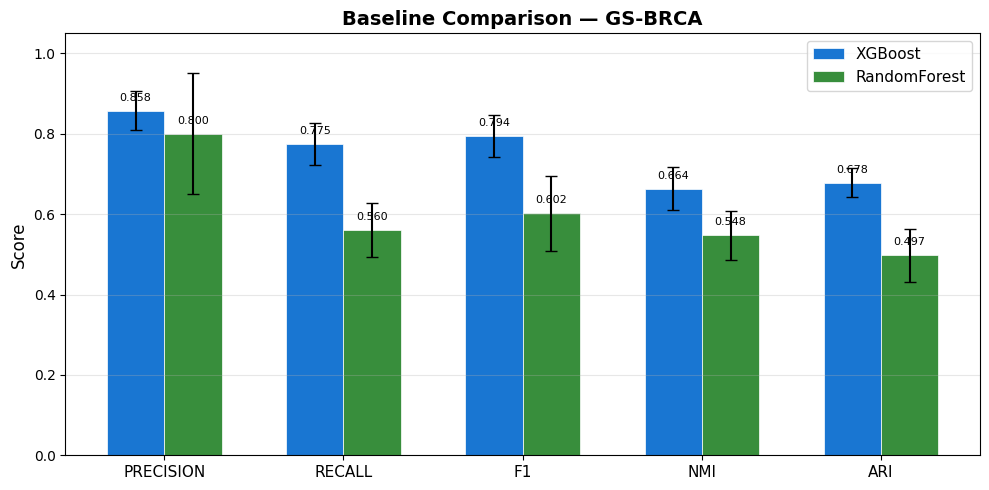

In [8]:
plot_comparison_bars('GS-BRCA')

Saved: baseline_comparison_COAD.png and .pdf


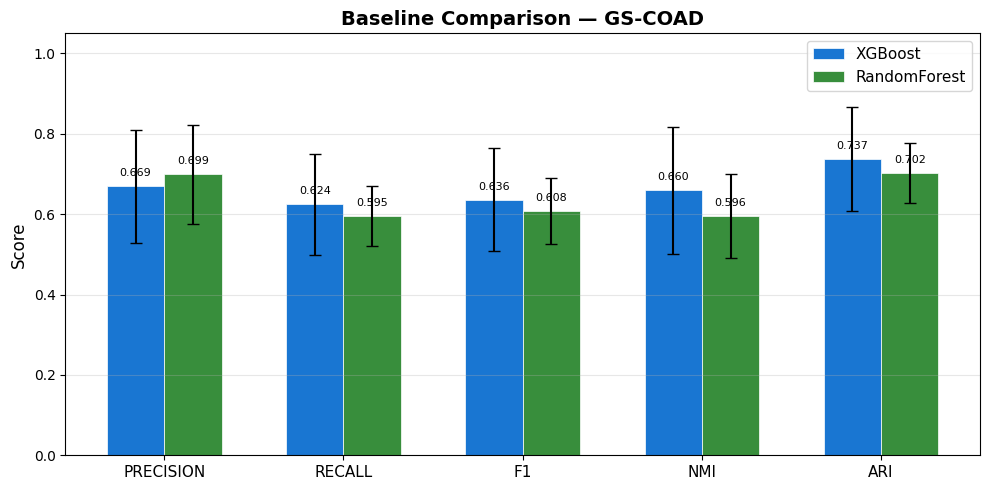

In [9]:
plot_comparison_bars('GS-COAD')

## 5 · Confusion Matrices

Best-fold confusion matrices for each model (generated during training).

### 5.1 · GS-BRCA

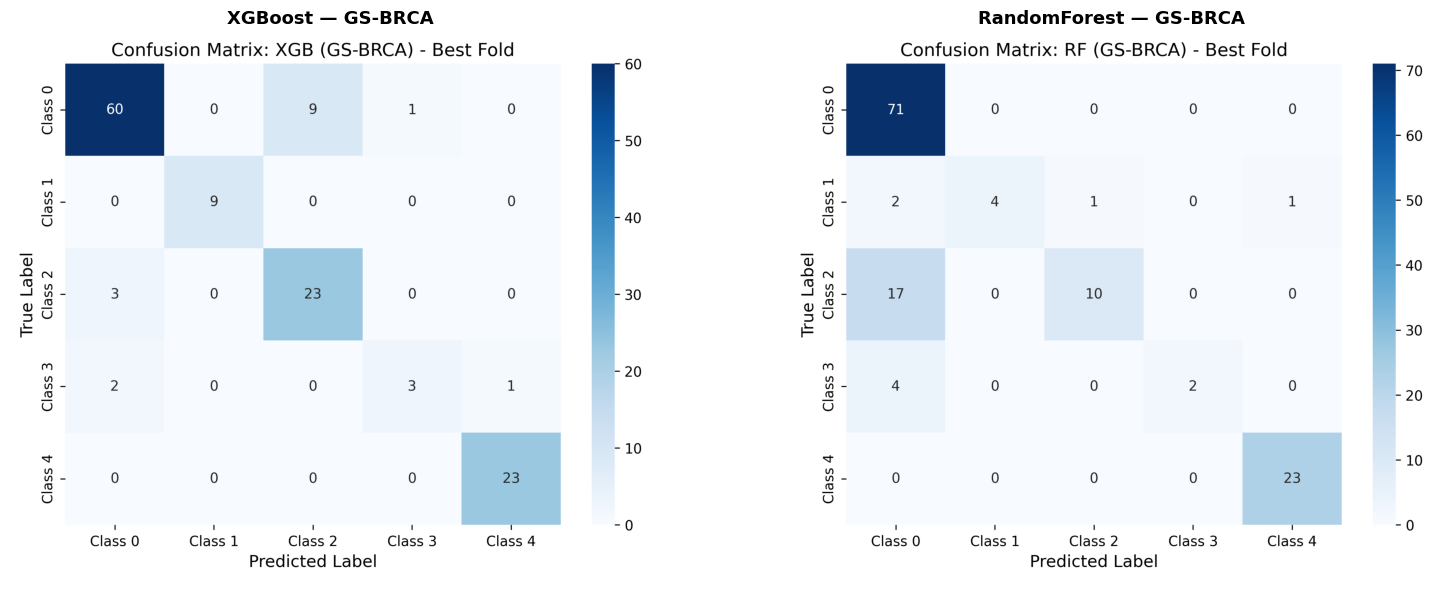

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (mk, label) in zip(axes, [('xgb', 'XGBoost'), ('rf', 'RandomForest')]):
    img_path = os.path.join(PLOTS_DIR, f'confusion_matrix_{mk}_BRCA.png')
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'{label} \u2014 GS-BRCA', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 5.2 · GS-COAD

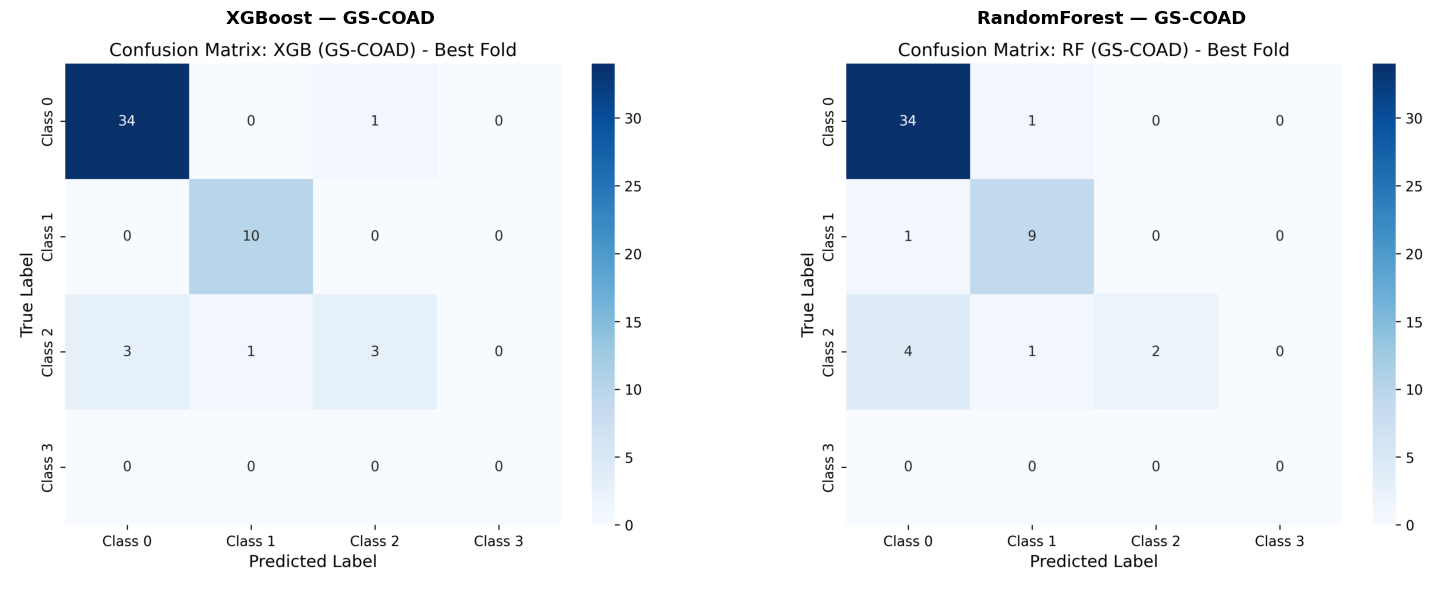

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (mk, label) in zip(axes, [('xgb', 'XGBoost'), ('rf', 'RandomForest')]):
    img_path = os.path.join(PLOTS_DIR, f'confusion_matrix_{mk}_COAD.png')
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'{label} \u2014 GS-COAD', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6 · SHAP Explainability

Top features identified by `TreeExplainer` on the best fold.

In [12]:
def load_top_features(model_key, cancer_short, n=10):
    path = os.path.join(SHAP_DIR, model_key, f'top_50_features_{model_key}_{cancer_short}.csv')
    df = pd.read_csv(path)
    df['modality_label'] = df['modality'].map(MODALITY_LABELS)
    df['gene'] = df['feature_name'].str.split('_', n=1).str[1]
    return df.head(n)

### 6.1 · GS-BRCA — Top 10 Features

In [13]:
for mk, label in [('xgb', 'XGBoost'), ('rf', 'RandomForest')]:
    top = load_top_features(mk, 'BRCA')
    display(Markdown(f'**{label} \u2014 GS-BRCA Top 10 by mean |SHAP|**'))
    show = top[['rank', 'gene', 'modality_label', 'mean_abs_shap']].copy()
    show.columns = ['Rank', 'Gene', 'Modality', 'Mean |SHAP|']
    display(show)

**XGBoost — GS-BRCA Top 10 by mean |SHAP|**

,Rank,Gene,Modality,Mean |SHAP|
0,1,MLPH,mRNA,0.405890
1,2,ESR1,mRNA,0.298670
2,3,MPHOSPH6,mRNA,0.257907
3,4,TOP2A,mRNA,0.168505
4,5,KCNMB1,mRNA,0.167221
5,6,UBE2T,mRNA,0.135668
6,7,SLC44A4,mRNA,0.111418
7,8,PPP1R14C,mRNA,0.110085
8,9,TFCP2L1,mRNA,0.096018
9,10,SERPINB5,mRNA,0.078658


**RandomForest — GS-BRCA Top 10 by mean |SHAP|**

,Rank,Gene,Modality,Mean |SHAP|
0,1,ESR1,mRNA,0.004959
1,2,MICALL1,mRNA,0.002616
2,3,GREB1,mRNA,0.002524
3,4,UBE2T,mRNA,0.002295
4,5,TTK,mRNA,0.002291
5,6,CCNB2,mRNA,0.002060
6,7,SMIM22,Methylation,0.001912
7,8,SMIM14,mRNA,0.001874
8,9,NAT1,mRNA,0.001852
9,10,CDC45,mRNA,0.001827


### 6.2 · GS-BRCA — SHAP Bar Plots

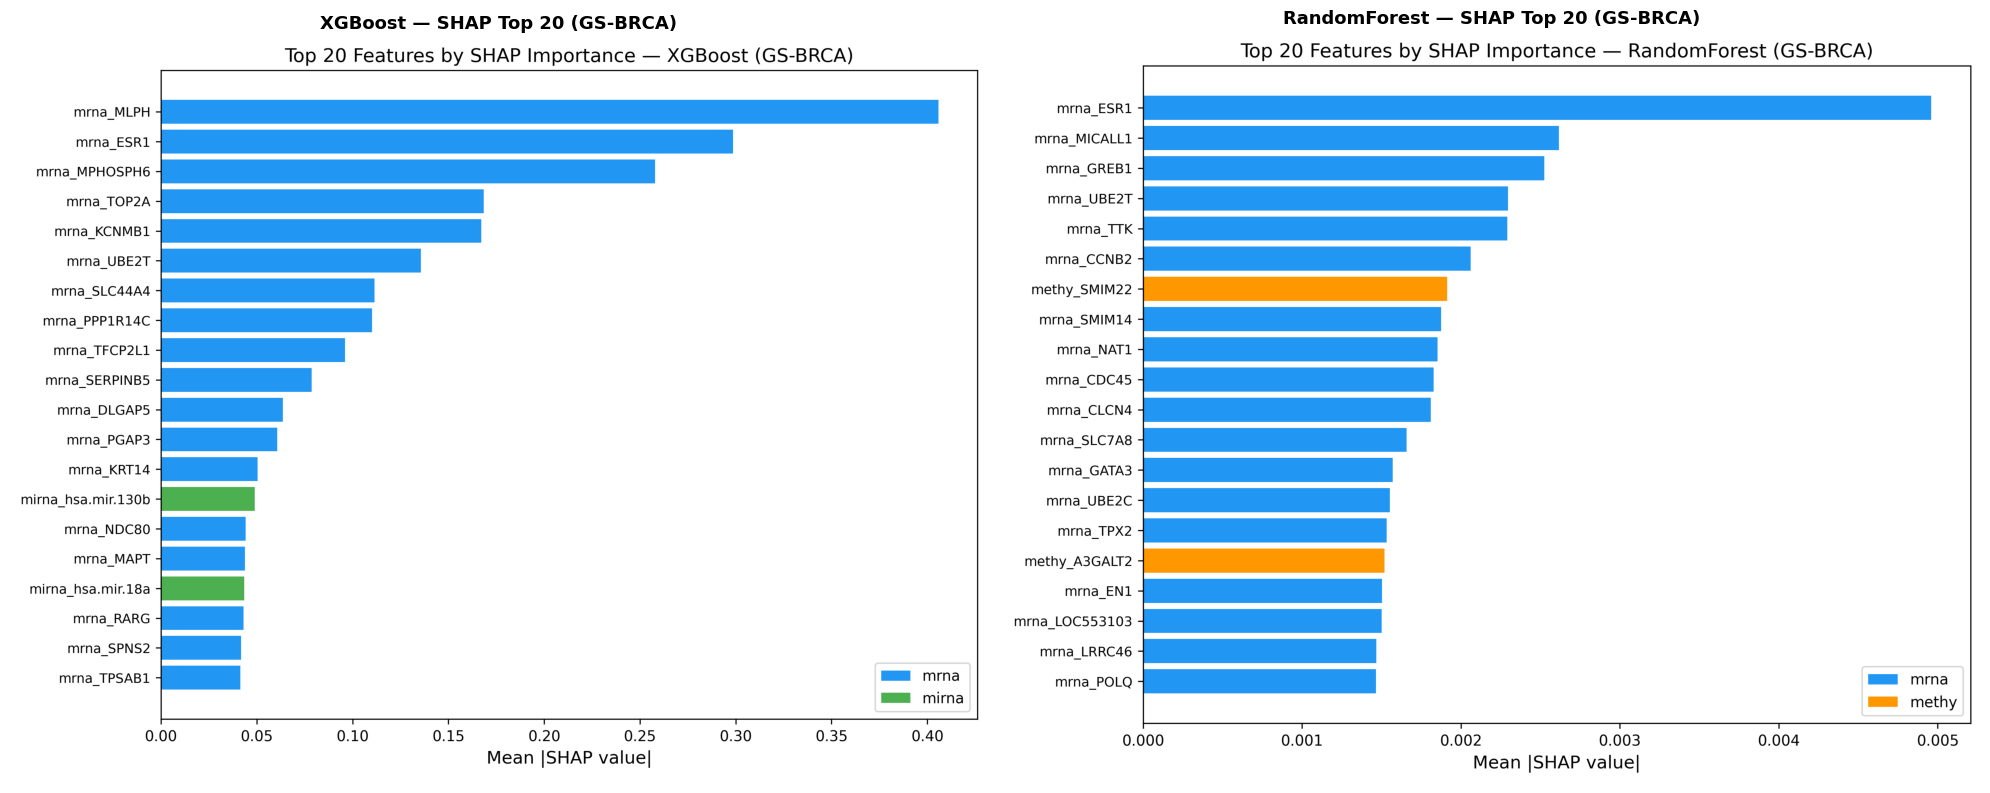

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (mk, label) in zip(axes, [('xgb', 'XGBoost'), ('rf', 'RandomForest')]):
    img_path = os.path.join(SHAP_DIR, mk, f'{mk}_shap_bar_BRCA.png')
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'{label} \u2014 SHAP Top 20 (GS-BRCA)', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 6.3 · GS-COAD — Top 10 Features

In [15]:
for mk, label in [('xgb', 'XGBoost'), ('rf', 'RandomForest')]:
    top = load_top_features(mk, 'COAD')
    display(Markdown(f'**{label} \u2014 GS-COAD Top 10 by mean |SHAP|**'))
    show = top[['rank', 'gene', 'modality_label', 'mean_abs_shap']].copy()
    show.columns = ['Rank', 'Gene', 'Modality', 'Mean |SHAP|']
    display(show)

**XGBoost — GS-COAD Top 10 by mean |SHAP|**

,Rank,Gene,Modality,Mean |SHAP|
0,1,MYO5B,CNV,0.251937
1,2,TIMM21,mRNA,0.232062
2,3,DCC,CNV,0.186250
3,4,SLC35A4,mRNA,0.167442
4,5,C4orf45,Methylation,0.143991
5,6,KCNRG,mRNA,0.138216
6,7,RIMKLB,Methylation,0.103249
7,8,A1CF,mRNA,0.080667
8,9,EOMES,CNV,0.079051
9,10,GAGE12J,Methylation,0.068663


**RandomForest — GS-COAD Top 10 by mean |SHAP|**

,Rank,Gene,Modality,Mean |SHAP|
0,1,MYO5B,CNV,0.003036
1,2,TCEB3B,CNV,0.002903
2,3,SERPINB7,CNV,0.002837
3,4,MOCOS,CNV,0.002721
4,5,C18orf42,CNV,0.002482
5,6,TIMM21,CNV,0.002481
6,7,SALL3,CNV,0.002145
7,8,SLC39A6,CNV,0.001927
8,9,EPG5,CNV,0.001890
9,10,DCC,CNV,0.001768


### 6.4 · GS-COAD — SHAP Bar Plots

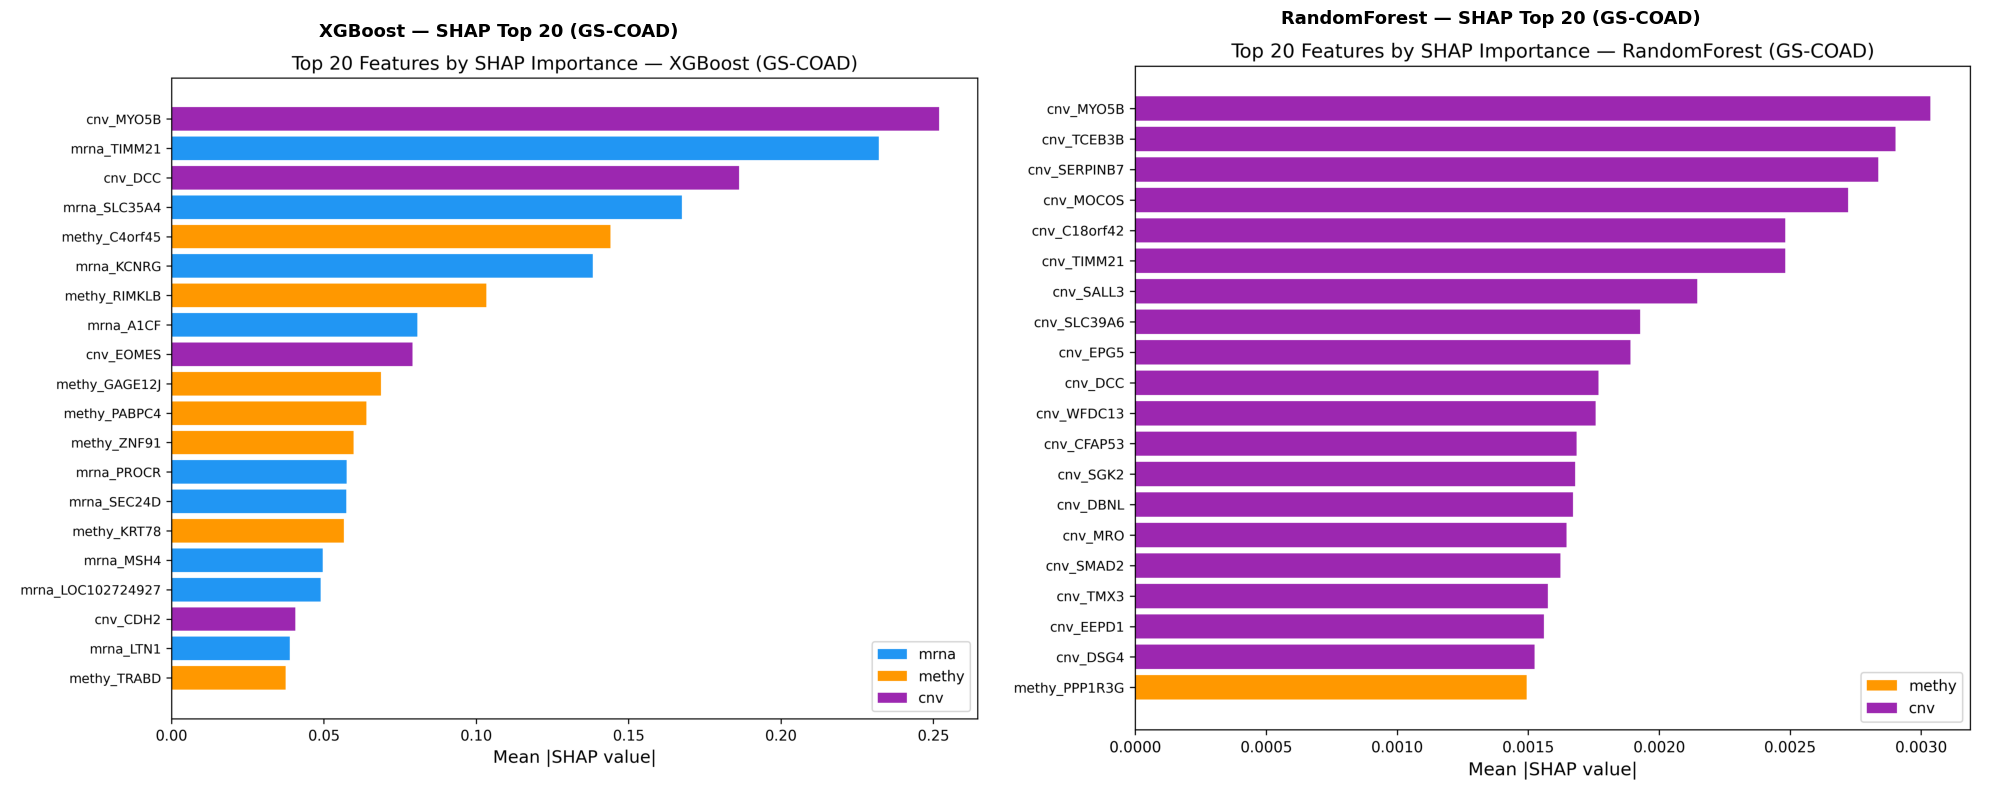

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (mk, label) in zip(axes, [('xgb', 'XGBoost'), ('rf', 'RandomForest')]):
    img_path = os.path.join(SHAP_DIR, mk, f'{mk}_shap_bar_COAD.png')
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f'{label} \u2014 SHAP Top 20 (GS-COAD)', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7 · Cross-Model Feature Agreement

In [17]:
for ct in CANCER_TYPES:
    cs = ct.split('-')[1]
    xgb_top = set(load_top_features('xgb', cs, n=20)['gene'])
    rf_top = set(load_top_features('rf', cs, n=20)['gene'])
    overlap = xgb_top & rf_top
    print(f'\n{ct} \u2014 Top-20 overlap: {len(overlap)} / 20')
    if overlap:
        print(f'  Shared genes: {sorted(overlap)}')
    else:
        print('  No shared genes in top 20')


GS-BRCA — Top-20 overlap: 2 / 20
  Shared genes: ['ESR1', 'UBE2T']

GS-COAD — Top-20 overlap: 3 / 20
  Shared genes: ['DCC', 'MYO5B', 'TIMM21']


## 8 · Discussion

### Which baseline is better?

The comparison table and bar charts reveal clear performance differences:

- **GS-BRCA:** XGBoost significantly outperforms RandomForest on F1 (multi-class,
  5 subtypes). XGBoost handles the high-dimensional, multi-class space more effectively
  through gradient-boosted sequential learning.

- **GS-COAD:** Both models perform comparably, with XGBoost having a slight edge.
  The smaller sample size (260 vs 671) and fewer classes (4 vs 5) reduce the gap.

### Are results consistent with expectations?

- Multi-class F1 scores of 0.60\u20130.80 are typical for cancer subtype classification
  using early fusion of ~15,000 features on datasets of this size.
- XGBoost\u2019s advantage aligns with published benchmarks where boosted trees often
  outperform bagging ensembles on tabular data.
- NMI and ARI metrics track F1 trends, confirming cluster-level consistency.

### SHAP insights

- **BRCA:** RF identifies ESR1 (estrogen receptor) as the top feature \u2014 a clinically
  established biomarker for ER+/ER- subtyping. Strong biological validation.
- **COAD:** Both models agree on MYO5B (CNV) as the top feature, suggesting
  copy-number alterations drive colorectal subtype classification.
- RF COAD relies heavily on CNV features (86% of top 50), while XGBoost uses a
  more balanced multi-modal mix \u2014 indicating different learned strategies.

### Limitations

- Features are pre-selected via global ANOVA (documented limitation).
- Early fusion (concatenation) does not model inter-modal interactions.
- The intermediate fusion model (Phase 5) is expected to address both.

> *Academic research prototype \u2014 not for clinical use.*